## **1. Install and import required labaries:**

In [103]:
pip install pandas numpy seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [104]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## **2. Read Data:**

In [105]:
df = pd.read_csv('insurance.csv')

## **3. Exploratory data analysis (EDA) and Data cleaning:**

In [106]:
df.shape

(1338, 7)

In [107]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [108]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [109]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [110]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [111]:
df.duplicated().sum()

np.int64(1)

In [112]:
df_cleaned = df.copy()

In [113]:
df_cleaned = df_cleaned.drop_duplicates().reset_index(drop=True)

In [114]:
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   str    
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   str    
 5   region    1337 non-null   str    
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.9 KB


### **Visualization of numeric columns:**

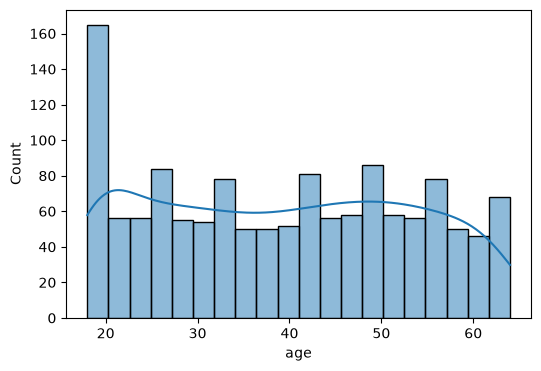

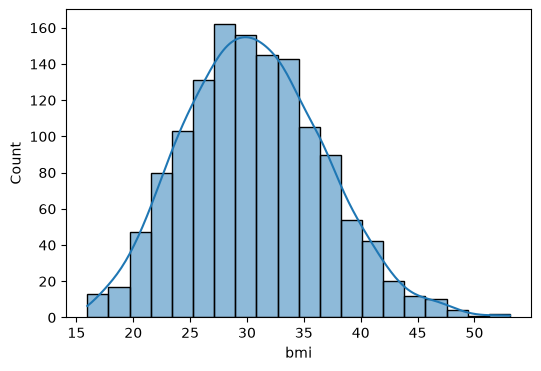

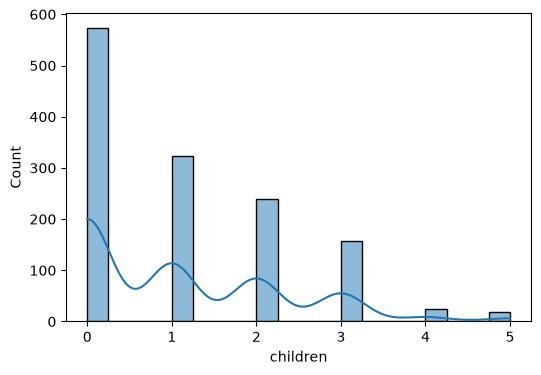

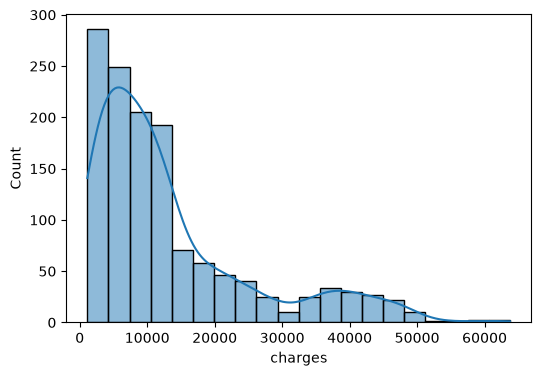

In [115]:
numeric_columns = ['age', 'bmi', 'children', 'charges']

for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df_cleaned[col], kde = True, bins = 20)

**Note:** Although children is a numeric column, it contains only a few discrete integer values. So, in the next step, I will use a count plot instead of a histogram to clearly show the frequency of each value.

### **Visualization of other columns:**

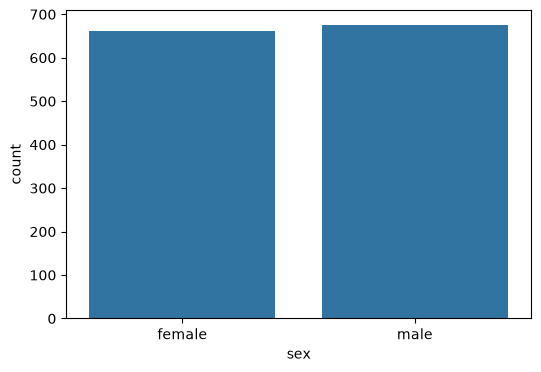

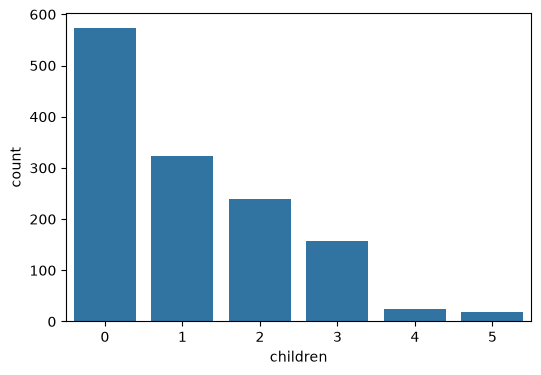

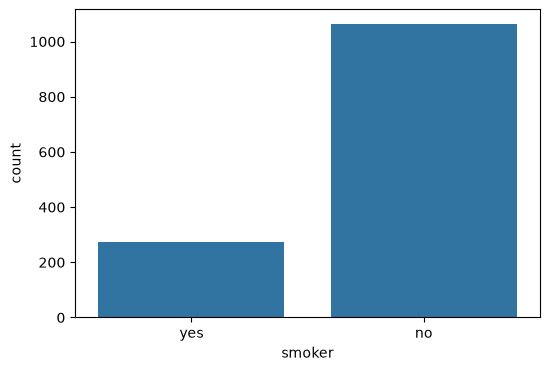

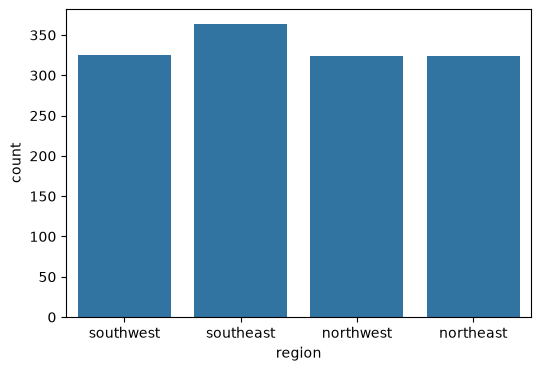

In [116]:
Other_columns = ['sex', 'children', 'smoker', 'region']

for col in Other_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x = df_cleaned[col])

<Axes: xlabel='children', ylabel='count'>

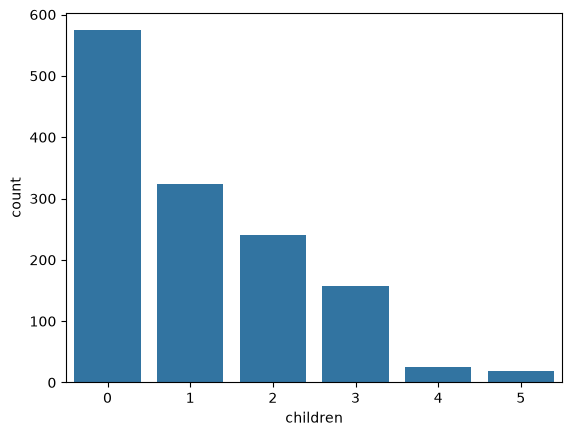

In [117]:
sns.countplot(x = df["children"])

### **Data Distribution and Outlier Detection for Numerical Variables:**

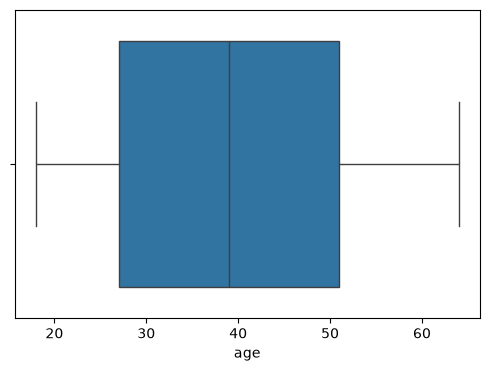

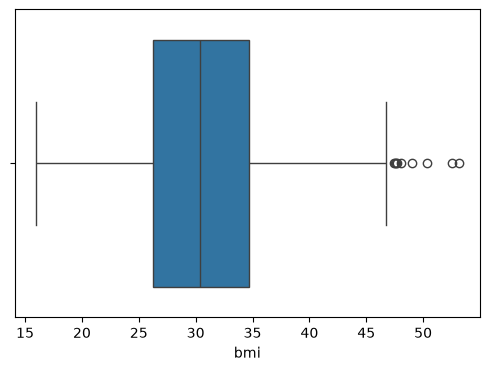

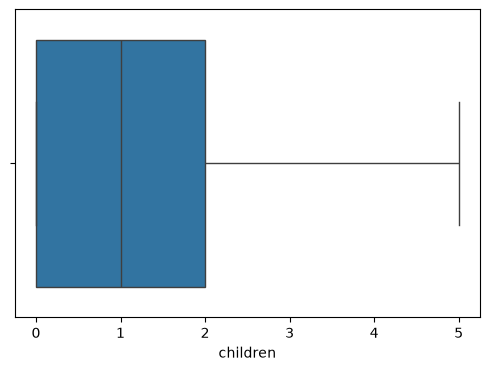

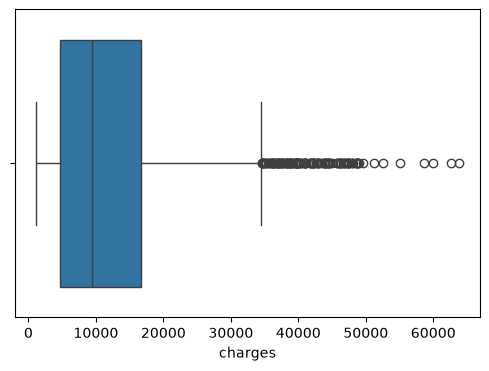

In [118]:
for col in numeric_columns:
    plt.figure(figsize= (6,4))
    sns.boxplot(x = df_cleaned[col])

**Interpretation:** The box plots indicate the presence of outliers in the BMI and charges variables.

### **Correlation Analysis Using Heatmap:**

<Axes: >

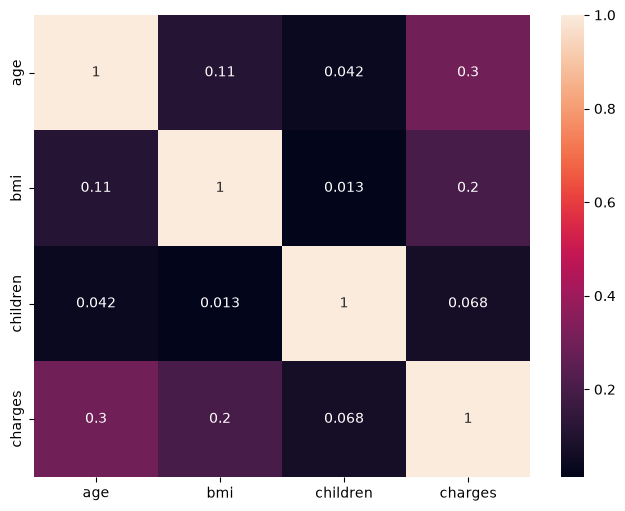

In [119]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)


**Interpretation:** The heatmap indicates that there are no strong correlations among the numerical variables. The highest correlation is between age and charges (0.30), followed by BMI and charges (0.20), both of which represent weak positive relationships. The remaining variable pairs exhibit negligible correlations, suggesting little to no linear relationship.

## **4. Feature Engineering:** For bussiness analysis.

In [120]:
df_feature = df_cleaned.copy()

In [121]:
df_feature['age_category'] = pd.cut(df_feature['age'],
                           bins= [17, 24, 34, 49, 64],
                           labels=['Young Adult', 'Adult', 'Middle Age', 'Older Adult'])

In [122]:
df_feature['bmi_category'] = pd.cut(
    df_feature['bmi'], 
    bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

In [123]:
df_feature

,age,sex,bmi,children,smoker,region,charges,age_category,bmi_category
0,19,female,27.900,0,yes,southwest,16884.92400,Young Adult,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Young Adult,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Adult,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Adult,Normal
4,32,male,28.880,0,no,northwest,3866.85520,Adult,Overweight
...,...,...,...,...,...,...,...,...,...
1332,50,male,30.970,3,no,northwest,10600.54830,Older Adult,Obese
1333,18,female,31.920,0,no,northeast,2205.98080,Young Adult,Obese
1334,18,female,36.850,0,no,southeast,1629.83350,Young Adult,Obese
1335,21,female,25.800,0,no,southwest,2007.94500,Young Adult,Overweight


**Checking the correlation:**

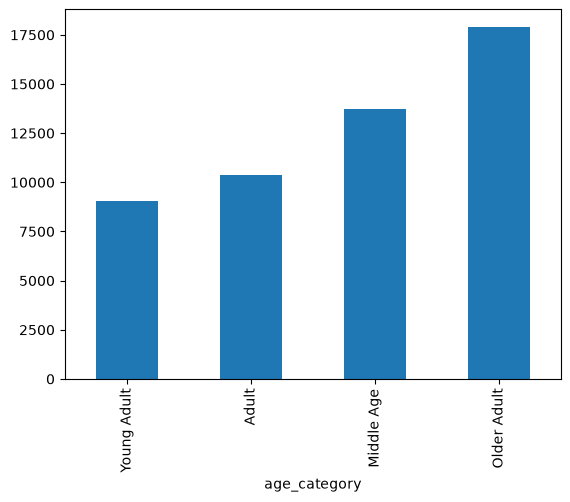

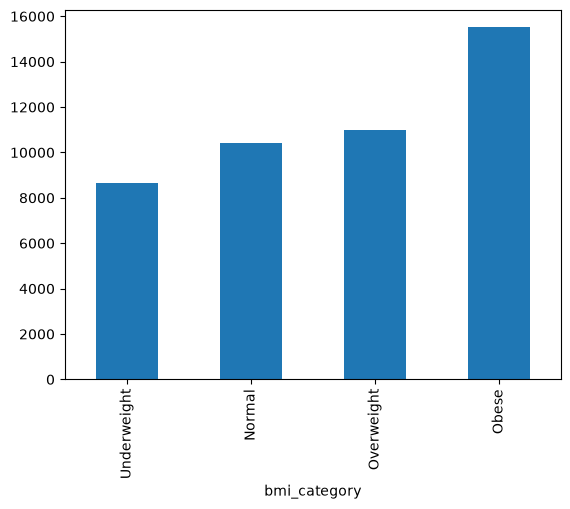

In [124]:
cols = ['age_category', 'bmi_category']

for col in cols:
    df_feature.groupby(col)['charges'].mean().plot(kind='bar')
    plt.show()

## **5. Data preprocessing:**

In [125]:
df_encoded = df_cleaned.copy()

### **Convert non-numeric data into numeric values for a machine learning model.:**

**Frequency Distribution of Categorical Variables:**

In [126]:
non_numeric = ['sex', 'smoker', 'region']

for col in non_numeric:
    print(df_encoded[col].value_counts())

sex
male      675
female    662
Name: count, dtype: int64
smoker
no     1063
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


**i. Apply mapping on sex & smoker column and rename both columns:**

In [127]:
mappings ={
    'sex': {'male': 0, 'female': 1},
    'smoker': {'no': 0, 'yes': 1}
}

for col, value in mappings.items():
      df_encoded[col] = df_encoded[col].map(value)

In [128]:
df_encoded.rename(columns={
    'sex': 'isfemale',
    'smoker' : 'issmoker'
}, inplace=True)

In [129]:
df_encoded.head()

,age,isfemale,bmi,children,issmoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


**ii. Applying One-Hot Encoding on other Categorical columns:**

In [130]:
df_encoded = pd.get_dummies(df_encoded, columns = ['region'], drop_first=False)

In [131]:
df_encoded.head()

,age,isfemale,bmi,children,issmoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False


**Convert data type to int:**

In [132]:
col_type = ['region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']

df_encoded[col_type] = df_encoded[col_type].astype(int)

In [133]:
df_encoded.head(10)

,age,isfemale,bmi,children,issmoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,0,1
1,18,0,33.770,1,0,1725.55230,0,0,1,0
2,28,0,33.000,3,0,4449.46200,0,0,1,0
3,33,0,22.705,0,0,21984.47061,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0
5,31,1,25.740,0,0,3756.62160,0,0,1,0
6,46,1,33.440,1,0,8240.58960,0,0,1,0
7,37,1,27.740,3,0,7281.50560,0,1,0,0
8,37,0,29.830,2,0,6406.41070,1,0,0,0
9,60,1,25.840,0,0,28923.13692,0,1,0,0


## **6. Feature Correlation with Target Variable:**
Measure how strongly each feature is related to the target variable.

In [134]:
df_encoded.columns

Index(['age', 'isfemale', 'bmi', 'children', 'issmoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest'],
      dtype='str')

In [135]:
from scipy.stats import pearsonr

#list of features to creck against target
selected_features = ['age', 'isfemale', 'bmi', 'children', 'issmoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest']

correlations = {
    feature: pearsonr(df_encoded[feature], df_encoded['charges'])[0]
    for feature in selected_features
    }
correlation_df = pd.DataFrame(list(correlations.items()), columns=['feature', 'pearson_correlation'])
correlation_df.sort_values(by='pearson_correlation', ascending=False)

,feature,pearson_correlation
5,charges,1.000000
4,issmoker,0.787234
0,age,0.298308
2,bmi,0.198401
8,region_southeast,0.073578
3,children,0.067389
6,region_northeast,0.005945
7,region_northwest,-0.038695
9,region_southwest,-0.043637
1,isfemale,-0.058044


## **7. Train Model:**

In [136]:
from sklearn.model_selection import train_test_split

In [137]:
x = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

In [138]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

**Create Model:**

In [139]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [140]:
models = {
    'Linear Regression' : LinearRegression(),

    'Ridge' : Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha = 1.0))
    ]),

    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),

    'Gradient Boosting': GradientBoostingRegressor(
        random_state=42
    )
}

results = []

for name, model in models.items():

    #train 
    model.fit(x_train, y_train)

    #prediction
    y_pred = model.predict(x_test)

    #evalution
    mean = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    #store results
    results.append({
        'Model': name,
        'Mean': mean,
        'RMSE': rmse,
        'R-square': r2
    })

results_df = pd.DataFrame(results)

results_df.sort_values('RMSE')

,Model,Mean,RMSE,R-square
3,Gradient Boosting,2561.128442,4299.114322,0.899419
2,Random Forest,2527.178967,4606.802726,0.884506
0,Linear Regression,4177.045561,5956.342894,0.806929
1,Ridge,4179.608448,5959.200057,0.806743


**Interpretation:** Gradient Boosting is the best model with the highest accuracy and lowest prediction error. Linear and Ridge models performed poorly, proving that the dataset contains complex, non-linear relationships.

In [141]:
from sklearn.model_selection import cross_val_score

In [142]:
cv_results = []

for name, model in models.items():

    scores = cross_val_score(model, x, y, cv=5, scoring='r2')


    cv_results.append({
        'Model': name,
        'Mean CV R²': scores.mean(),
        'Std CV R²': scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df.sort_values(
    'Mean CV R²',
    ascending=False
)

,Model,Mean CV R²,Std CV R²
3,Gradient Boosting,0.854435,0.031160
2,Random Forest,0.838486,0.033598
1,Ridge,0.746745,0.024627
0,Linear Regression,0.746738,0.024706


**Interpretation:** Gradient Boosting remains the best-performing model, with a mean CV R² of 0.854. The relatively low standard deviation (0.031) indicates that its performance is reasonably consistent across different folds.

**Save best model:**

In [143]:
best_model = models['Gradient Boosting']

**Hyperparameter Tuning:**

In [145]:
from sklearn.model_selection import GridSearchCV

In [146]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4]
}

grid_search = GridSearchCV(
    estimator=best_model,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.03, 0.05, ...], 'max_depth': [2, 3, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbo

In [147]:
print(grid_search.best_params_)

{'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}


**Build Tuned Model:**

In [148]:
final_model = grid_search.best_estimator_

In [149]:
final_pred = final_model.predict(x_test)

**Final Evaluation:**

In [150]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [151]:
final_mae = mean_absolute_error(y_test, final_pred)

final_rmse = mean_squared_error(
    y_test,
    final_pred
) ** 0.5

final_r2 = r2_score(y_test, final_pred)

print("Final MAE:", final_mae)
print("Final RMSE:", final_rmse)
print("Final R²:", final_r2)

Final MAE: 2474.9867388290063
Final RMSE: 4263.3517115730365
Final R²: 0.90108534425015


**Final Model Save:**

In [152]:
import joblib


In [153]:
joblib.dump(
    final_model,
    'insurance_charge_model.pkl'
)

joblib.dump(
    x.columns.tolist(),
    'feature_columns.pkl'
)

['feature_columns.pkl']